# AIE S2 — Bank Term Deposit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s2-bank-marketing.ipynb)

**Classification.** A Portuguese bank ran a direct marketing
campaign: 45,211 calls, and for each one, whether the client
subscribed a term deposit afterwards. Predict that outcome for calls
you have not been shown.

Challenge: <https://ml-arena.com/viewchallenge/184>

---

**This notebook contains no code, and that is deliberate.** You have
just read the bike-demand notebook, which is the same five steps on a
regression target. Here the steps are written and the
cells are empty. Write them yourself.

Two things genuinely differ from the bike challenge, and both are
flagged below where they bite: the target is a **class**, not a
quantity, and it is **imbalanced** — only 11.7% of clients said yes.

---

## 0. Setup

Install the ML-Arena client. `pandas`, `seaborn` and `scikit-learn`
are already available in Colab.

The distribution is **`mlarena-sdk`** and it imports as `mlarena`.
`pip install mlarena`

In [149]:
!pip install -q mlarena-sdk

---

## 1. Get the data

Connect with your personal `mlk_user_...` key from your ML-Arena
Profile page, and download the dataset for challenge **184**
into the working directory. Same two calls as last time.

In [150]:
import mlarena 

CHALLENGE_ID = "184"
API_KEY = "mlk_user_1b593eaa7623ad7a_f72264e89cb5705131fe449d19783d2f"

client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID, ".")

['./X_train.csv', './X_test.csv', './y_train.csv']

---

## 2. Read it

Load `X_train.csv`, the `prediction` column of `y_train.csv`, and
`X_test.csv`.

Then answer three questions before going further:

- What are **n** and **p**?
- Which columns are numeric and which are text?
- **What fraction of the training target is 1?** Compute it now. This
  number decides your metric and your reading of every result that
  follows.

In [151]:
import pandas as pd

X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")
X_test = pd.read_csv("X_test.csv")

print("X_train :",X_train.shape, "y_train :", y_train.shape, "X_test :", X_test.shape)
X_train.head(3)

X_train : (36168, 17) y_train : (36168, 2) X_test : (9043, 17)


,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,tr_8b4549bd884a,35,services,married,secondary,no,44,yes,no,telephone,17,apr,377,2,-1,0,unknown
1,tr_5c0f32a83c1f,41,blue-collar,married,primary,no,402,no,no,unknown,17,jun,114,17,-1,0,unknown
2,tr_2513d28bb205,39,services,married,secondary,no,-404,yes,no,cellular,11,may,344,1,-1,0,unknown


In [152]:
#on print le nombre de valeurs possible pour les prediction de y
print("y_train :", y_train.shape, "valeurs possibles :", y_train.nunique())

#on print la part de 1 dans predictions dans y_train
print("y_train :", y_train.shape, "part de 1 :", y_train["prediction"].sum() / y_train.shape[0])
y_train.head(3)

y_train : (36168, 2) valeurs possibles : id            36168
prediction        2
dtype: int64
y_train : (36168, 2) part de 1 : 0.11698186241981863


,id,prediction
0,tr_8b4549bd884a,0
1,tr_5c0f32a83c1f,0
2,tr_2513d28bb205,0


In [153]:

print("Type des colonnes de X_train :")
X_train.dtypes

Type des colonnes de X_train :


,0
id,object
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object


In [154]:
X_train.describe()

,age,balance,day,duration,campaign,pdays,previous
count,36168.000000,36168.00000,36168.000000,36168.000000,36168.000000,36168.000000,36168.000000
mean,40.892999,1365.49342,15.817961,258.506940,2.763935,40.157238,0.581730
std,10.627075,3068.54350,8.331980,259.142445,3.104161,100.162614,2.408766
min,18.000000,-8019.00000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,74.00000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,451.00000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1430.25000,21.000000,318.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.00000,31.000000,4918.000000,63.000000,871.000000,275.000000


---

## 3. Look at it

Aim for five or six plots. For each one, ask what decision it changes.

**3a. The target.** Count the two classes. Confirm the imbalance you
computed above, and work out what accuracy you would get by always
predicting the majority class. Write that number down; it is the
number your model has to be judged against.

**3b. A numeric feature against the target.** Compare the
distribution of `duration` (call length in seconds) for clients who
subscribed and clients who did not. A boxplot or a pair of histograms
will do. The separation is large — then read the note in step 4 about
why that should make you uneasy rather than pleased.

**3c. A categorical feature against the target.** Plot the
**subscription rate** — not the raw count — per level of `poutcome`
(the outcome of the previous campaign), `month`, and `job`. Raw counts
will mostly tell you which levels are common; the rate is what tells
you which are predictive. `groupby(col)[target].mean()` gives it to
you directly.

**3d. Age.** Plot the subscription rate against age in bins. It is not
monotone. Note what that means for a model that multiplies age by a
single coefficient.

**3e. Two more columns that look like quantities.** Do the same rate
plot for `day` (day of the month, 1-31) and for `duration` cut into
deciles — 3b showed you `duration`'s distribution, this is its rate.
Neither one climbs in a straight line. Write down, for each, the
single sentence a lone coefficient would be forced to say about it;
with your age plot from 3d that is three notes you will need in
step 7.

**3f. Correlation.** Heatmap the numeric columns. Check whether any
pair is nearly redundant.

**3g. `pdays`.** Look at its distribution. The value `-1` is a flag
meaning "never previously contacted", not a quantity — so the column
mixes a category and a measurement in one place. Decide what to do
about it, and be able to say why.

In [155]:
print("Accuracy à battre :")
print(1-y_train["prediction"].mean())

Accuracy à battre :
0.8830181375801813


In [156]:
#on crée le df en matchant l'id de X_train et y_train
df = pd.merge(X_train, y_train, on="id")
df.head(3)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,prediction
0,tr_8b4549bd884a,35,services,married,secondary,no,44,yes,no,telephone,17,apr,377,2,-1,0,unknown,0
1,tr_5c0f32a83c1f,41,blue-collar,married,primary,no,402,no,no,unknown,17,jun,114,17,-1,0,unknown,0
2,tr_2513d28bb205,39,services,married,secondary,no,-404,yes,no,cellular,11,may,344,1,-1,0,unknown,0


Text(0.5, 1.0, 'Durée des appels selon la prédiction')

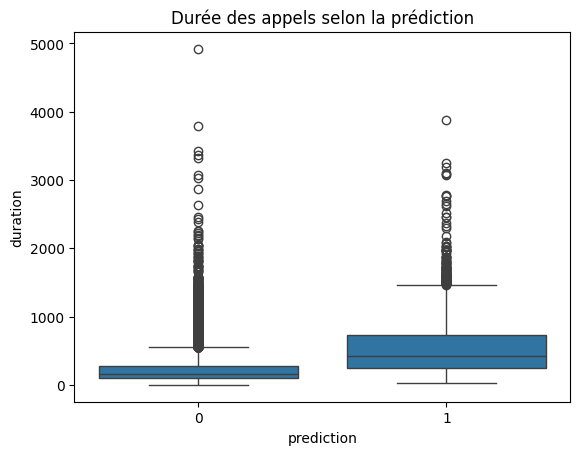

In [157]:
#on plot la moyenne, le min et le max (et toute les durées possibles) selon la colonne "duration" de X_train et on compare par prediction de y_train
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()

sns.boxplot(x="prediction",y="duration", data=df, ax=ax)
ax.set_title("Durée des appels selon la prédiction")

**3c. A categorical feature against the target.** Plot the
**subscription rate** — not the raw count — per level of `poutcome`
(the outcome of the previous campaign), `month`, and `job`. Raw counts
will mostly tell you which levels are common; the rate is what tells
you which are predictive. `groupby(col)[target].mean()` gives it to
you directly.

In [158]:
df.dtypes

,0
id,object
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object


Text(0.5, 1.0, 'Subrate selon le job')

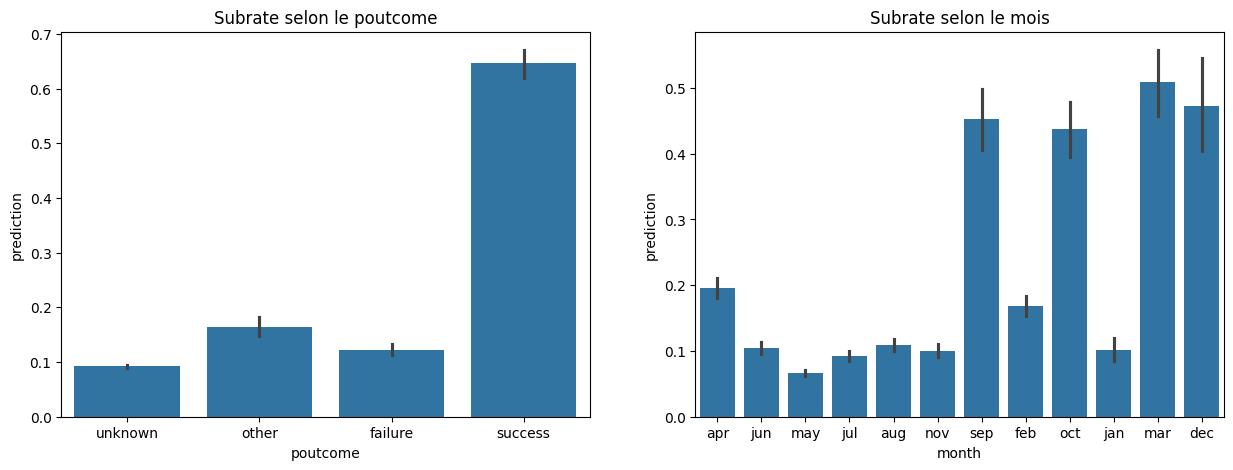

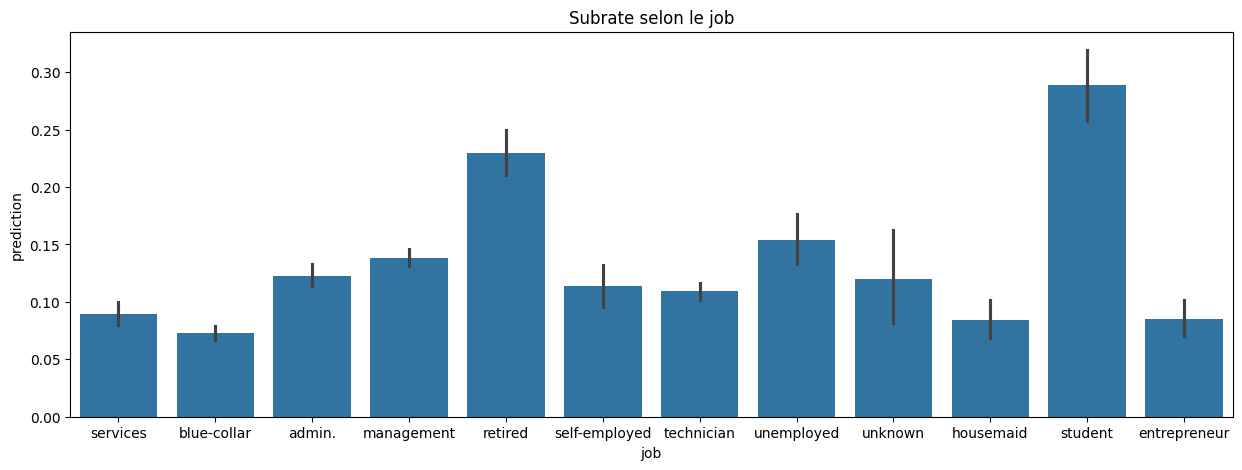

In [159]:

fig, ax = plt.subplots(1,2, figsize=(15,5))




sns.barplot(data=df, x="poutcome",y="prediction", estimator="mean", ax=ax[0]) 
ax[0].set_title("Subrate selon le poutcome")

sns.barplot(data=df, x="month",y="prediction", estimator="mean", ax=ax[1])
ax[1].set_title("Subrate selon le mois")

fig, ax = plt.subplots(1,figsize=(15,5))
sns.barplot(data=df, x="job",y="prediction", estimator="mean")
ax.set_title("Subrate selon le job")


**3d. Age.** Plot the subscription rate against age in bins. It is not
monotone. Note what that means for a model that multiplies age by a
single coefficient.



Text(0.5, 1.0, "Distribution de l'age selon le subrate")

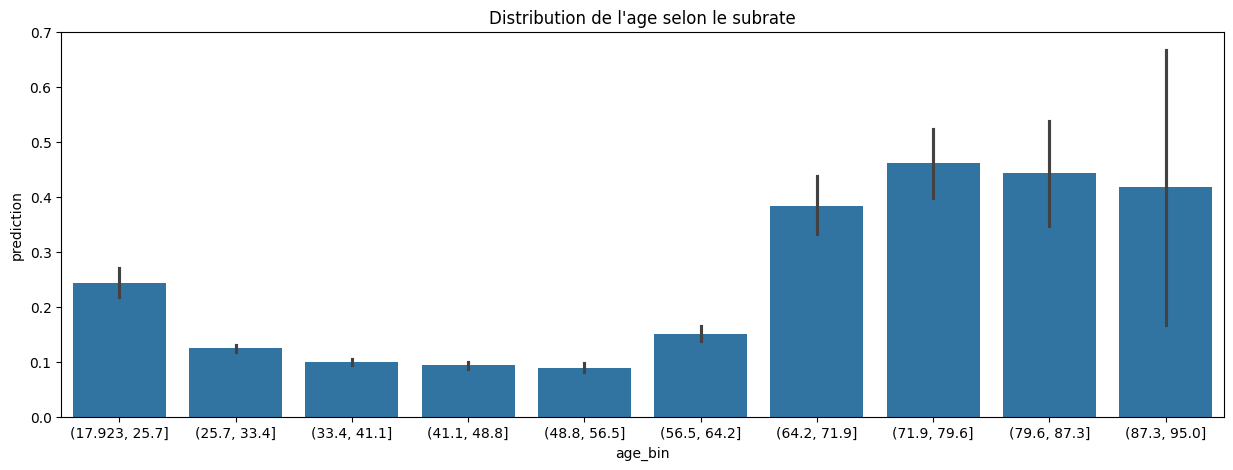

In [160]:
df["age_bin"] = pd.cut(df["age"], bins=10)

fig, ax = plt.subplots(1,figsize=(15,5))
sns.barplot(data=df, x="age_bin",y="prediction", estimator="mean")
ax.set_title("Distribution de l'age selon le subrate")

**3e. Two more columns that look like quantities.** Do the same rate
plot for `day` (day of the month, 1-31) and for `duration` cut into
deciles — 3b showed you `duration`'s distribution, this is its rate.
Neither one climbs in a straight line. Write down, for each, the
single sentence a lone coefficient would be forced to say about it;
with your age plot from 3d that is three notes you will need in
step 7.


In [161]:

def calculate_day_of_week(day, month): #donne juste un chiffre de 0 à 6 correspondant au jour de la semaine en partant du 1er janvier
    month_number= {"jan" : 0, "feb" : 1, "mar" : 2, "apr" : 3, "may" : 4, "jun" : 5, "jul" : 6, "aug" : 7, "sep" : 8, "oct" : 9, "nov" : 10, "dec" : 11}
    month_days = [31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30, 31]
    return (day + sum(month_days[:month_number[month]]) -4) % 7
    

Text(0.5, 1.0, 'Distribution de la durée selon le subrate')

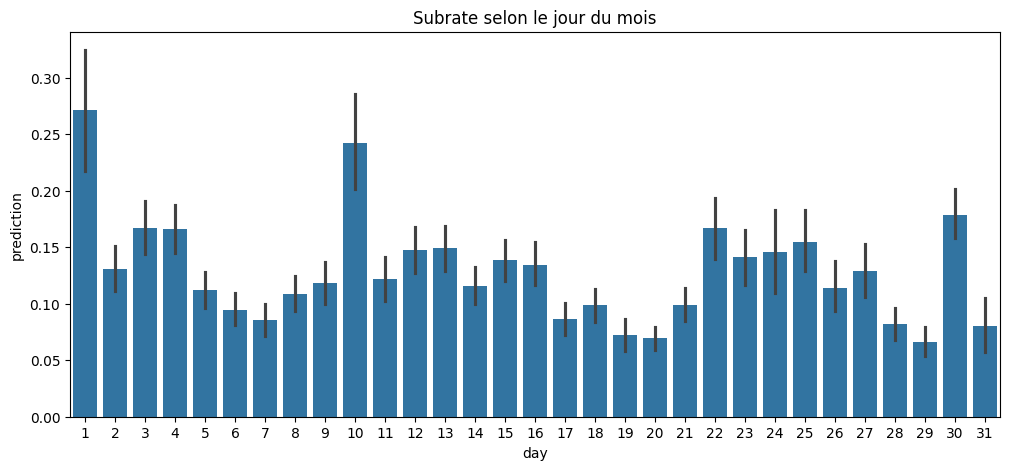

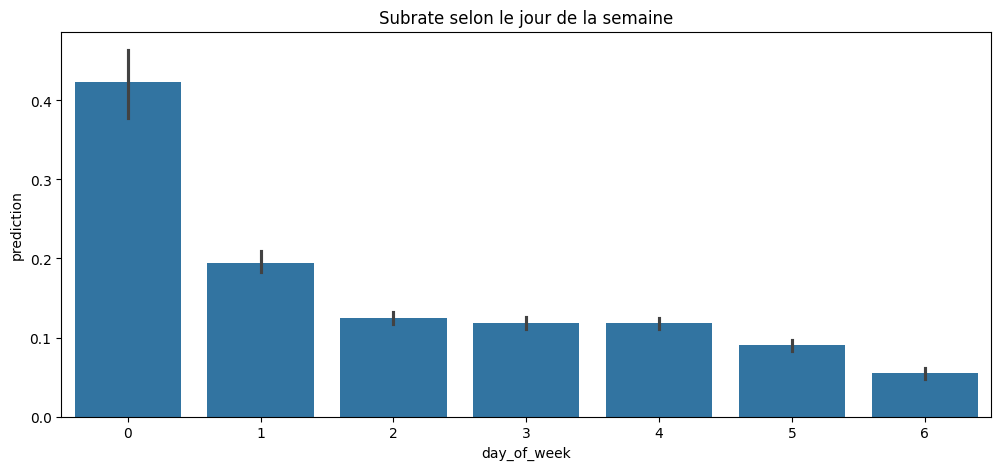

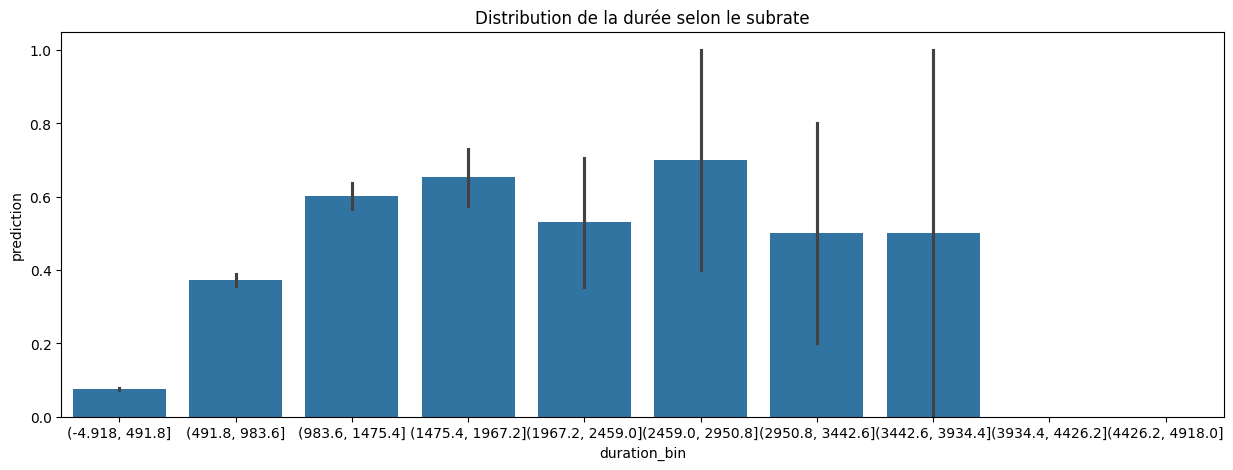

In [162]:
fig, ax = plt.subplots(1, figsize=(12, 5))
sns.barplot(data=df, y="prediction", x="day",estimator="mean")
ax.set_title("Subrate selon le jour du mois")

df["day_of_week"] = df.apply(lambda row: calculate_day_of_week(row["day"], row["month"]), axis=1)
fig,ax = plt.subplots(1, figsize=(12, 5))
sns.barplot(data=df, y="prediction", x="day_of_week",estimator="mean")
ax.set_title("Subrate selon le jour de la semaine")

fig, ax = plt.subplots(1, figsize=(15,5))
df["duration_bin"] = pd.cut(df["duration"], bins=10)
sns.barplot(data=df, x="duration_bin",y="prediction", estimator="mean")
ax.set_title("Distribution de la durée selon le subrate")




**3f. Correlation.** Heatmap the numeric columns. Check whether any
pair is nearly redundant.



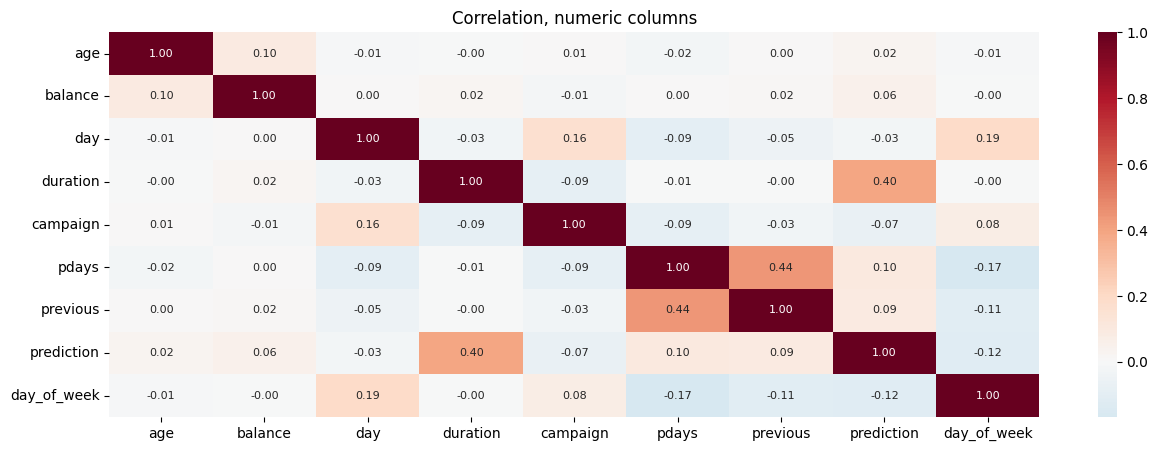

In [163]:
numeric_columns = df.select_dtypes("number") 
fig, ax = plt.subplots(1, figsize=(15,5))
sns.heatmap(numeric_columns.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation, numeric columns")
plt.show()

**3g. `pdays`.** Look at its distribution. The value `-1` is a flag
meaning "never previously contacted", not a quantity — so the column
mixes a category and a measurement in one place. Decide what to do
about it, and be able to say why.

In [164]:
#on ajoute une colone "contacted" à la place du flag -1 de pdays pour savoir si le client a été contacté ou non
df["contacted"] = df["pdays"].apply(lambda x: 0 if x == -1 else 1)

---

## 4. Turn it into numbers

Same problem as before: nine of the sixteen columns are text. One-hot
encode them, and align the test columns to the training ones — an
encoding done independently on the two frames will not match.

**Then scale the numeric columns.** This is the step the bike notebook
did not need. `balance` runs from −8,019 to 102,127 while `campaign`
runs from 1 to 63; the solver behind `LogisticRegression` will not
converge in a sensible number of iterations if you hand it both
untouched. `StandardScaler` fitted on the training matrix is enough.

**A decision to make here.** `duration` is the length of the call you
are predicting the outcome of. You only know it once the call has
ended — so a model that relies on it could never run *before* placing
the call. It is in the data and you may use it. Decide whether you
want to, and say why in a comment. Both answers are defensible; an
unexamined answer is not.

In [165]:
#on regarde si on a des trous dans les colonnes numériques

X_train.select_dtypes("number").isnull().sum()
X_train.select_dtypes("object").isnull().sum()
X_train.select_dtypes("object").isna().sum()

,0
id,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
poutcome,0


In [166]:
#On fais du one hot sur les colonnes de texte

X_dotw = X_train.copy()
X_dotw["day_of_the_week"] = X_train.apply(lambda row: calculate_day_of_week(row["day"], row["month"]), axis=1)
 
# Réaligner y_train selon l'ordre des id présents dans X_train
y_train_aligned = (
    y_train
    .set_index("id")
    .loc[X_train["id"], "prediction"]
    .reset_index(drop=True)
)

X_train_enc = pd.get_dummies(
    X_dotw.drop(columns=["id"])
)

X_test_dotw = X_test.copy()
X_test_dotw["day_of_the_week"] = X_test.apply(lambda row: calculate_day_of_week(row["day"], row["month"]), axis=1)
X_test_enc = pd.get_dummies(
    X_test_dotw.drop(columns=["id"])
).reindex(
    columns=X_train_enc.columns,
    fill_value=0
)


print(X_train_enc.shape)
print(X_test_enc.shape)
X_train_enc.head(3)



(36168, 52)
(9043, 52)


,age,balance,day,duration,campaign,pdays,previous,day_of_the_week,job_admin.,job_blue-collar,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,35,44,17,377,2,-1,0,5,False,False,...,False,False,False,False,False,False,False,False,False,True
1,41,402,17,114,17,-1,0,3,False,True,...,True,False,False,False,False,False,False,False,False,True
2,39,-404,11,344,1,-1,0,1,False,False,...,False,False,True,False,False,False,False,False,False,True


---

## 5. Fit it and read the numbers

Fit `LogisticRegression` on the training matrix and score it on those
same rows. As in the bike notebook, that is deliberate: this session
measures the fit on the data it was fitted to, which a model with one
coefficient per column can be trusted to answer honestly. Session 3 is
where you learn to measure it properly.

Report **four** numbers: accuracy, precision, recall and F1. Then:

- Compare your accuracy with the always-predict-0 accuracy from step
  3a. If they are close, your accuracy is telling you nothing.
- Look at precision against recall. A model that almost never predicts
  1 will have decent precision and terrible recall, and F1 is the
  number that refuses to let you ignore that.
- A confusion matrix makes all four legible at once. Plot it.

The challenge ranks on **F1 on the positive class**, for exactly the
reason step 3a made visible.

In [171]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, recall_score, precision_score, f1_score, accuracy_score
import numpy as np
from sklearn.preprocessing import StandardScaler

X_train_enc_scaled = StandardScaler().fit_transform(X_train_enc)

model = LogisticRegression().fit(X_train_enc_scaled, y_train_aligned)
pred = model.predict(X_train_enc_scaled)


print("Recall :" )
print(recall_score(y_train_aligned, pred_hot))
print("Precision :" )
print(precision_score(y_train_aligned, pred_hot))
print("F1 :" )
print(f1_score(y_train_aligned, pred_hot))
print("Accuracy :" )
print(accuracy_score(y_train_aligned, pred_hot))


Recall :
0.34956275112266605
Precision :
0.6515418502202643
F1 :
0.45500692201199816
Accuracy :
0.9020404777704047


---

## 6. The threshold is yours

`predict()` labels a client as 1 when the predicted probability
exceeds 0.5. That 0.5 is a convention, not a property of the problem,
and on a target that is 11.7% positive it is rarely the best choice.

Use `predict_proba()` to get the probabilities, then:

- Sweep the threshold from 0.05 to 0.60 and plot F1 against it.
- Read off the best one and keep it.

On this dataset the move is worth more than changing model family —
it is worth about **0.13 of F1**, and no model in Session 3 will buy
you that. Sweep it here, in the notebook; the leaderboard gives you
one number per submission and is not a search space.

[0.09730297 0.00656176 0.09221673 ... 0.71673614 0.0200066  0.04250944]
fpr : [0.00000000e+00 3.13116448e-05 3.13116448e-05 ... 9.91451921e-01
 9.91451921e-01 1.00000000e+00]
tpr : [0.00000000e+00 0.00000000e+00 2.36350745e-04 ... 9.99763649e-01
 1.00000000e+00 1.00000000e+00]
thresholds : [           inf 9.99999949e-01 9.99996354e-01 ... 2.70584218e-03
 2.70404107e-03 4.71606813e-05]
AUC : 0.9096212647496366


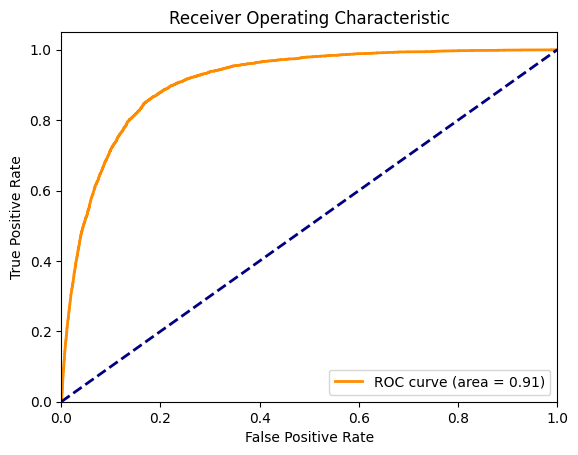

In [172]:
#on plot le ROC pour connaitre le threshold optimal pour le modèle de regression linéaire
from sklearn.metrics import roc_curve, auc

pred = model.predict_proba(X_train_enc_scaled)[:, 1]  # Probabilities for the positive class

print(pred)

fpr, tpr, thresholds = roc_curve(y_train_aligned, pred)
print("fpr :", fpr)
print("tpr :", tpr)
print("thresholds :", thresholds)

import matplotlib.pyplot as plt

roc_auc = auc(fpr, tpr)
print("AUC :", roc_auc)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Best threshold : 0.2


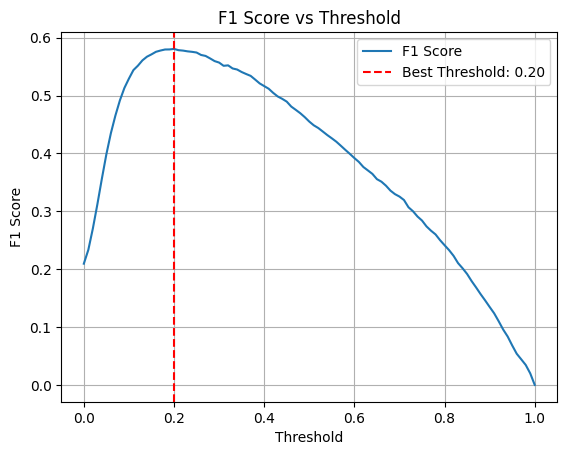

In [173]:
#on va tracer le f1 score par threshold 

theresholds = np.arange(0.0, 1.01, 0.01)
f1_scores = [f1_score(y_train_aligned, np.where(pred > t, 1, 0)) for t in theresholds]

best_threshold = theresholds[np.argmax(f1_scores)]
print("Best threshold :", best_threshold)

#on plot pour 9 thresholds + le meilleur threshold pour voir l'évolution du f1 score 
plt.plot(theresholds, f1_scores, label='F1 Score')
plt.axvline(x=best_threshold, color='red', linestyle='--', label=f'Best Threshold: {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs Threshold')
plt.legend()
plt.grid()
plt.show()


In [174]:
#on regarde recall, accuracy, precision et f1 score pour le meilleur threshold
pred_best_threshold = np.where(pred > best_threshold, 1, 0)
print("Recall :" )
print(recall_score(y_train_aligned, pred_best_threshold))
print("Precision :" )
print(precision_score(y_train_aligned, pred_best_threshold))
print("F1 :" )
print(f1_score(y_train_aligned, pred_best_threshold))
print("Accuracy :" )
print(accuracy_score(y_train_aligned, pred_best_threshold))

Recall :
0.6787993382179154
Precision :
0.5071516863853082
F1 :
0.5805538710329493
Accuracy :
0.8852576863525768


---

## 7. Go further: put the shapes you saw into the columns

The threshold was the cheap move and you have spent it. What is left
is the move the model cannot make for itself.

`LogisticRegression` gets **one coefficient per column**. About a
numeric column it can therefore say exactly two things — *more is
likelier* or *less is likelier* — and nothing else. Go back to your
plots from step 3 and ask of each one: **can a single coefficient say
this?** Where it cannot, the fix is a column, not a bigger model.

Three of your figures should already have answered no. Cutting a
column into bins and letting `get_dummies` make one indicator per
bin gives the model a free number per bin, which is exactly the
shape a rate plot that goes down and then up requires.

Then look for the other two moves from the *Data Preparation*
lesson: a **transform** for a column whose scale is wildly skewed,
and an **interaction** where the effect of one column plainly depends
on another.

**Check before you add.** `get_dummies` has already been at the nine
text columns, and one flag you may be about to build by hand is
sitting in that matrix twice already. Compare `X.pdays == -1` against
`poutcome == 'unknown'` and against `previous == 0` before you write
the line — one of those agreements is exact and the other is off by
five rows in 36,168. A column that duplicates one you have buys
nothing and costs you a coefficient.

**Measure one move at a time**, and re-run your step-6 threshold
sweep after each: a change that helps at a fixed 0.5 can be worth
nothing once the threshold is free to move, and you cannot tell which
happened if you changed six columns at once. Keep a move only if it
moves the F1.

For calibration: the baseline with a tuned threshold lands near
**F1 = 0.58**, and re-cut columns are worth roughly
**+0.01 to +0.02** on top of it. That is a smaller gain than the
threshold bought you, and it is the honest size of the effect —
the point of the step is the reasoning, not the third decimal.

In [210]:
# On repart de X_train
X_train_7 = X_train.copy()
X_test_7 = X_test.copy()

X_train_7["balance_log"] = np.sign(X_train_7["balance"]) * np.log1p(
    np.abs(X_train_7["balance"])
)
X_test_7["balance_log"] = np.sign(X_test_7["balance"]) * np.log1p(
    np.abs(X_test_7["balance"])
)

X_train_7["day_of_week"] = X_train_7.apply(
    lambda row: calculate_day_of_week(row["day"], row["month"]),
    axis=1
)
X_test_7["day_of_week"] = X_test_7.apply(
    lambda row: calculate_day_of_week(row["day"], row["month"]),
    axis=1
)

X_train_7["day"] = X_train_7["day"].astype(str)
X_test_7["day"] = X_test_7["day"].astype(str)
X_train_7["day_of_week"] = X_train_7["day_of_week"].astype(str)
X_test_7["day_of_week"] = X_test_7["day_of_week"].astype(str)

X_train_7.head(3)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,balance_log,day_of_week
0,tr_8b4549bd884a,35,services,married,secondary,no,44,yes,no,telephone,17,apr,377,2,-1,0,unknown,3.806662,5
1,tr_5c0f32a83c1f,41,blue-collar,married,primary,no,402,no,no,unknown,17,jun,114,17,-1,0,unknown,5.998937,3
2,tr_2513d28bb205,39,services,married,secondary,no,-404,yes,no,cellular,11,may,344,1,-1,0,unknown,-6.003887,1


In [211]:
# On crée les bins à partir de X_train uniquement
def make_bins(data, column, number_of_bins=10):
    edges = np.unique(
        data[column].quantile(np.linspace(0, 1, number_of_bins + 1)).to_numpy()
    )
    return edges

for column, number_of_bins in [("age", 10), ("duration", 20)]:
    edges = make_bins(X_train_7, column, number_of_bins)
    X_train_7[f"{column}_bin"] = pd.cut(
        X_train_7[column], bins=edges, include_lowest=True
    ).astype(str)
    X_test_7[f"{column}_bin"] = pd.cut(
        X_test_7[column], bins=edges, include_lowest=True
    ).astype(str)

X_train_7[["age_bin", "duration_bin", "day"]].head(3)

,age_bin,duration_bin,day
0,"(34.0, 36.0]","(367.0, 438.0]",17
1,"(39.0, 42.0]","(103.0, 117.0]",17
2,"(36.0, 39.0]","(318.0, 367.0]",11


In [212]:
# On encode les catégories et on aligne X_test sur X_train
X_train_7 = X_train_7.drop(columns=["id"])
X_test_7 = X_test_7.drop(columns=["id"])

X_train_7 = pd.get_dummies(X_train_7)
X_test_7 = pd.get_dummies(X_test_7).reindex(
    columns=X_train_7.columns,
    fill_value=0
)

print(X_train_7.shape)
print(X_test_7.shape)

(36168, 119)
(9043, 119)


In [213]:
# On scale les colonnes numériques avec X_train uniquement
numeric_columns_7 = X_train_7.select_dtypes(include="number").columns
scaler_7 = StandardScaler()

X_train_7[numeric_columns_7] = scaler_7.fit_transform(
    X_train_7[numeric_columns_7]
)
X_test_7[numeric_columns_7] = scaler_7.transform(
    X_test_7[numeric_columns_7]
)

X_train_7.head(3)

,age,balance,duration,campaign,pdays,previous,balance_log,job_admin.,job_blue-collar,job_entrepreneur,...,"duration_bin_(279.0, 318.0]","duration_bin_(318.0, 367.0]","duration_bin_(35.0, 58.0]","duration_bin_(367.0, 438.0]","duration_bin_(438.0, 549.0]","duration_bin_(549.0, 757.0]","duration_bin_(58.0, 75.0]","duration_bin_(75.0, 89.0]","duration_bin_(757.0, 4918.0]","duration_bin_(89.0, 103.0]"
0,-0.554535,-0.430664,0.457257,-0.246104,-0.41091,-0.241509,-0.286451,False,False,False,...,False,False,False,True,False,False,False,False,False,False
1,0.010069,-0.313995,-0.557643,4.586187,-0.41091,-0.241509,0.290287,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.178132,-0.576664,0.329912,-0.568256,-0.41091,-0.241509,-2.867386,False,False,False,...,False,True,False,False,False,False,False,False,False,False


In [214]:
# On entraîne la régression logistique
from sklearn.linear_model import LogisticRegression

model_7 = LogisticRegression(max_iter=2000)
model_7.fit(X_train_7, y_train_aligned)

pred_7 = model_7.predict_proba(X_train_7)[:, 1]
print("Score moyen :", pred_7.mean())

Score moyen : 0.1169552591023105


Best threshold : 0.2
Best F1 : 0.595671656020593


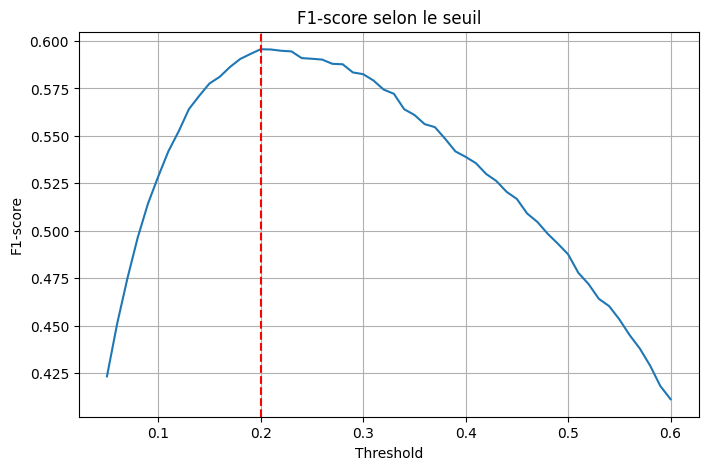

In [215]:
# On cherche le seuil qui maximise le F1
from sklearn.metrics import f1_score

thresholds_7 = np.arange(0.05, 0.61, 0.01)
f1_scores_7 = [
    f1_score(y_train_aligned, (pred_7 >= threshold).astype(int))
    for threshold in thresholds_7
]

best_threshold_7 = thresholds_7[np.argmax(f1_scores_7)]
print("Best threshold :", best_threshold_7)
print("Best F1 :", max(f1_scores_7))

plt.figure(figsize=(8, 5))
plt.plot(thresholds_7, f1_scores_7)
plt.axvline(best_threshold_7, color="red", linestyle="--")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.title("F1-score selon le seuil")
plt.grid()
plt.show()

In [209]:
# On regarde les métriques avec le meilleur seuil
pred_best_threshold_7 = (pred_7 >= best_threshold_7).astype(int)

print("Accuracy :", accuracy_score(y_train_aligned, pred_best_threshold_7))
print("Recall :", recall_score(y_train_aligned, pred_best_threshold_7))
print("Precision :", precision_score(y_train_aligned, pred_best_threshold_7))
print("F1 :", f1_score(y_train_aligned, pred_best_threshold_7))

Accuracy : 0.884981198849812
Recall : 0.7248877333963601
Precision : 0.5058551872010556
F1 : 0.5958810957839518


---

## 8. Predict the test set and write the submission

Refit on all the training data — with whatever column recipe you
kept from step 7, applied identically to `X_test` — predict, and
apply the threshold you chose.

The submission is `submission.csv` with columns `id` and `prediction`,
one row per test id. **`prediction` must be the integer 0 or 1** — a
probability is rejected outright rather than thresholded for you.

Assert the three things before uploading: one row per test id, ids
unique, and every value in {0, 1}.

In [216]:
# On prédit X_test avec les mêmes transformations que X_train
X_test_proba_7 = model_7.predict_proba(X_test_7)[:, 1]
X_test_prediction_7 = (
    X_test_proba_7 >= best_threshold_7
).astype(int)

submission = pd.DataFrame({
    "id": X_test["id"],
    "prediction": X_test_prediction_7
})

submission.to_csv("submission.csv", index=False)
submission.head()

,id,prediction
0,te_a2bc08ec9a5a,0
1,te_cbc8d2c09b81,1
2,te_9640e460876f,0
3,te_8b1163c7040d,0
4,te_007f0d690d2b,0


In [217]:
# On vérifie que la soumission est conforme
assert len(submission) == len(X_test)
assert submission["id"].is_unique
assert submission["prediction"].notna().all()
assert set(submission["prediction"].unique()).issubset({0, 1})
assert list(submission.columns) == ["id", "prediction"]

print("submission.csv conforme")
print(submission.shape)

submission.csv conforme
(9043, 2)


---

## 9. Submit

Submit the file and look at the leaderboard. The challenge page has
the ladder to read yourself against: F1 = 0.453 is the baseline at
the default threshold, 0.581 is that same model at 0.20, and 0.592
is it again on re-cut columns.

Below 0.453, the likely reasons in order: you left the threshold at
0.5, you did not scale, or your test columns are misaligned with your
training columns. Around 0.58 you found the threshold. Above that you
found something in step 7 as well.

In [218]:
# On envoie la soumission
result = client.submit(
    challenge_id=CHALLENGE_ID,
    files=["submission.csv"]
)
print(result)

{'attache_agent_id': 8602, 'agent_id': 8602, 'deploy': {'deployment_id': 8369, 'message': 'Deployment started successfully', 'status': 'deploy_queue'}}
